In [1]:
#import libraries 

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import time

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.preprocessing import MinMaxScaler

In [2]:
from plotly.offline import iplot, init_notebook_mode
import plotly.graph_objs as go
import plotly.io as pio


#import extra_graphs

In [3]:
#Read Csvfile

dtframe=pd.read_csv("Connected_Vehicles_UWE_Dataset.csv")

dtframe.head(5)

,VEHICLE IDENTIFICATION OTONOMO ID,FUELTYPE,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP START,TRIP END,TRIP LENGTH MINUTES
0,003217527c9a5ad89e8bb00374ee9d37,ICE,54.95903,54.95903,-1.74675,-1.74670,12.353081,32.870536,1/1/2022 5:52,1/1/2022 6:02,10
1,003217527c9a5ad89e8bb00374ee9d37,ICE,54.95903,54.95904,-1.74670,-1.74668,12.783539,32.789758,1/2/2022 5:45,1/2/2022 5:54,9
2,003217527c9a5ad89e8bb00374ee9d37,ICE,54.95904,54.95905,-1.74668,-1.74668,9.964760,30.565249,1/3/2022 5:37,1/3/2022 5:46,9
3,003217527c9a5ad89e8bb00374ee9d37,ICE,54.95905,54.95900,-1.74668,-1.74672,6.608753,28.483655,1/3/2022 12:27,1/3/2022 12:44,17
4,003217527c9a5ad89e8bb00374ee9d37,ICE,54.95900,54.95893,-1.74672,-1.74670,28.475833,57.576255,1/3/2022 13:25,1/3/2022 13:53,28


In [4]:
#Print shape
dtframe.shape

(191978, 11)

In [5]:
#View Index, Datatype and Memory usage
dtframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191978 entries, 0 to 191977
Data columns (total 11 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   VEHICLE IDENTIFICATION OTONOMO ID  191978 non-null  object 
 1   FUELTYPE                           191978 non-null  object 
 2   LOCATION LAT START                 191978 non-null  float64
 3   LOCATION LAT END                   191978 non-null  float64
 4   LOCATION LONG START                191978 non-null  float64
 5   LOCATION LONG END                  191978 non-null  float64
 6   MOBILITY SPEED AVERAGE             191950 non-null  float64
 7   MOBILITY SPEEDMAXIMUM              191950 non-null  float64
 8   TRIP START                         191978 non-null  object 
 9   TRIP END                           191978 non-null  object 
 10  TRIP LENGTH MINUTES                191978 non-null  int64  
dtypes: float64(6), int64(1), object(4)
memo

In [6]:
# Check NUll values
pd.isnull(dtframe)

,VEHICLE IDENTIFICATION OTONOMO ID,FUELTYPE,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP START,TRIP END,TRIP LENGTH MINUTES
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
191973,False,False,False,False,False,False,False,False,False,False,False
191974,False,False,False,False,False,False,False,False,False,False,False
191975,False,False,False,False,False,False,False,False,False,False,False
191976,False,False,False,False,False,False,False,False,False,False,False


In [7]:
# Describe data set 

dtframe.describe()

,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP LENGTH MINUTES
count,191978.000000,191978.000000,191978.000000,191978.000000,191950.000000,191950.000000,191978.000000
mean,54.718290,54.718208,-0.433399,-0.433438,13.388854,37.852868,19.641568
std,1.520294,1.520076,1.832632,1.832394,8.506058,16.365480,20.932548
min,40.458670,40.459180,-7.532440,-7.532380,0.000000,0.000000,1.000000
25%,53.365576,53.365077,-1.366746,-1.366318,7.163291,27.296836,7.000000
50%,54.775108,54.775795,-0.245261,-0.245254,11.892837,34.591734,14.000000
75%,55.478118,55.478107,0.636191,0.635882,17.668630,47.621888,25.000000
max,62.028830,62.060374,11.106298,11.108297,71.708474,113.213831,605.000000


In [8]:
pd.notnull(dtframe)

,VEHICLE IDENTIFICATION OTONOMO ID,FUELTYPE,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP START,TRIP END,TRIP LENGTH MINUTES
0,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
191973,True,True,True,True,True,True,True,True,True,True,True
191974,True,True,True,True,True,True,True,True,True,True,True
191975,True,True,True,True,True,True,True,True,True,True,True
191976,True,True,True,True,True,True,True,True,True,True,True


In [9]:
#Backup Data Set
bkpdtframe=dtframe

#Reomve all rows missing values
dtframe = dtframe.dropna()
dtframe.shape

(191950, 11)

In [10]:
dtframe['FUELTYPE'].unique()

array(['ICE', 'EV', 'Hybrid ', 'Unknown'], dtype=object)

In [11]:
# Import label encoder 
# Fuel type --- EV,Hybrid, ICE, Unknown

from sklearn import preprocessing


#fuel_types=('EV','Hybrid','ICE','Unknown')
#fuel_df = pd.DataFrame(fuel_types, columns=['Fuel_Types'])

# label_encoder object knows how to understand word labels. 

label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'FUELTYPE'. 
dtframe["FUELTYPE"]= label_encoder.fit_transform(dtframe["FUELTYPE"]) 

#dtframe["VEHICLE IDENTIFICATION OTONOMO ID"]= label_encoder.fit_transform(dtframe["VEHICLE IDENTIFICATION OTONOMO ID"])

C:\Users\himan\AppData\Local\Temp/ipykernel_17228/3468262430.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [12]:
dtframe.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 191950 entries, 0 to 191977
Data columns (total 11 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   VEHICLE IDENTIFICATION OTONOMO ID  191950 non-null  object 
 1   FUELTYPE                           191950 non-null  int32  
 2   LOCATION LAT START                 191950 non-null  float64
 3   LOCATION LAT END                   191950 non-null  float64
 4   LOCATION LONG START                191950 non-null  float64
 5   LOCATION LONG END                  191950 non-null  float64
 6   MOBILITY SPEED AVERAGE             191950 non-null  float64
 7   MOBILITY SPEEDMAXIMUM              191950 non-null  float64
 8   TRIP START                         191950 non-null  object 
 9   TRIP END                           191950 non-null  object 
 10  TRIP LENGTH MINUTES                191950 non-null  int64  
dtypes: float64(6), int32(1), int64(1), obje

In [13]:
dtframe.describe()

,FUELTYPE,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP LENGTH MINUTES
count,191950.000000,191950.000000,191950.000000,191950.000000,191950.000000,191950.000000,191950.000000,191950.000000
mean,0.963798,54.718290,54.718207,-0.433391,-0.433430,13.388854,37.852868,19.641615
std,1.014997,1.520322,1.520103,1.832660,1.832422,8.506058,16.365480,20.930925
min,0.000000,40.458670,40.459180,-7.532440,-7.532380,0.000000,0.000000,1.000000
25%,0.000000,53.365547,53.365020,-1.366746,-1.366318,7.163291,27.296836,7.000000
50%,0.000000,54.775075,54.775790,-0.245253,-0.245251,11.892837,34.591734,14.000000
75%,2.000000,55.478126,55.478124,0.635945,0.635880,17.668630,47.621888,25.000000
max,3.000000,62.028830,62.060374,11.106298,11.108297,71.708474,113.213831,605.000000


In [14]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data = pd.DataFrame({'index':[0,1,2,3],
        'FUELTYPE':['ICE','EV','Hybrid ','Unknown']})
data['FUELTYPE_Encoded'] = le.fit_transform(data['FUELTYPE'].values)
data = data.drop_duplicates('FUELTYPE').set_index('index')
print(data)

      FUELTYPE  FUELTYPE_Encoded
index                           
0          ICE                 2
1           EV                 0
2      Hybrid                  1
3      Unknown                 3


In [15]:
import scipy.stats as stats


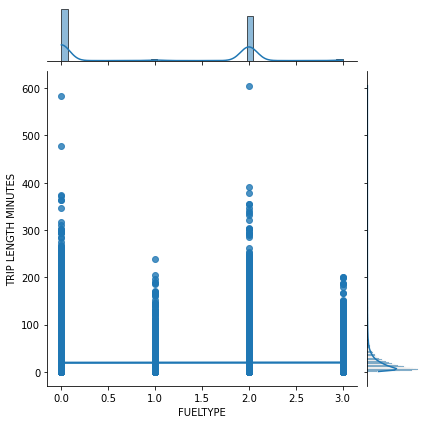

In [16]:
# add code here 

sns.jointplot(x="FUELTYPE", y="TRIP LENGTH MINUTES", data=dtframe, kind='reg');


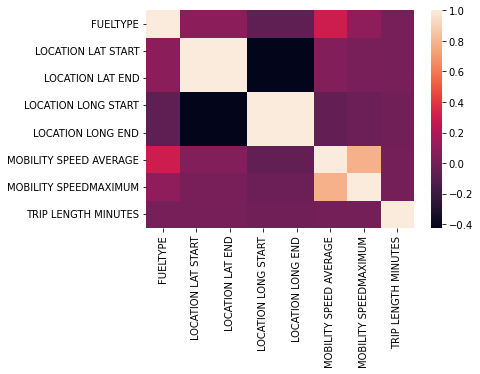

In [17]:
dataplot=sns.heatmap(dtframe.corr())
plt.show()

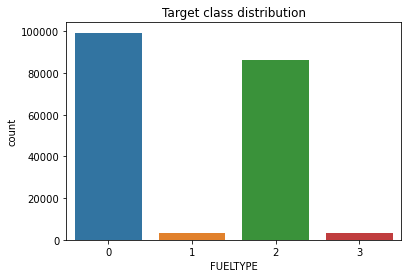

In [18]:
ax = plt.axes()
sns.countplot(x='FUELTYPE', data=dtframe, ax=ax);
ax.set_title('Target class distribution')
plt.show()

In [19]:
#Splitting Data into Test and Train Sets


cols = [col for col in dtframe.columns if col not in ['FUELTYPE']]
#X is data except the target variable
X_Complete_data = dtframe[cols]
# Create the target vector
y_Complete_data = dtframe['FUELTYPE']

In [20]:
Test_data = dtframe[dtframe['FUELTYPE']==-1]
Test_data.head(5)

,VEHICLE IDENTIFICATION OTONOMO ID,FUELTYPE,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP START,TRIP END,TRIP LENGTH MINUTES


In [21]:
cols = [col for col in Test_data.columns if col not in ['FUELTYPE']]
#X is data except the target variable
X_Test_data = Test_data[cols]
# Create the target vector
y_Test_data = Test_data['FUELTYPE']
y_Test_data[:]= 0
y_Test_data.shape

C:\Users\himan\AppData\Local\Temp/ipykernel_17228/234545802.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\himan\anaconda3\lib\site-packages\pandas\core\series.py:1105: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(0,)

In [22]:
dtframe.drop('TRIP START',axis =1,inplace=True)
dtframe.drop('TRIP END',axis =1,inplace=True)
dtframe["VEHICLE IDENTIFICATION OTONOMO ID"]= label_encoder.fit_transform(dtframe["VEHICLE IDENTIFICATION OTONOMO ID"])
# dtframe.drop('VEHICLE IDENTIFICATION OTONOMO ID',axis =1,inplace=True)

C:\Users\himan\anaconda3\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\himan\AppData\Local\Temp/ipykernel_17228/1835273953.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [23]:
#dtframe["FUELTYPE"] = np.where(dtframe["FUELTYPE"] == "EV", 1, 0)

In [24]:
dtframe = dtframe.dropna(axis=0, subset=['FUELTYPE'])
#data.drop(data['shot_made_flag']=-1)
dtframe=dtframe[dtframe.FUELTYPE != -1]
dtframe['FUELTYPE'].head(5)

0    2
1    2
2    2
3    2
4    2
Name: FUELTYPE, dtype: int32

In [25]:
cols = [col for col in dtframe.columns if col not in ['FUELTYPE']]
#X is data except the target variable
X = dtframe[cols]
# Create the target vector
y = dtframe['FUELTYPE']
#Split Train and Test
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
 y,
test_size=0.1,
random_state=1)
X_train.head(5)

,VEHICLE IDENTIFICATION OTONOMO ID,LOCATION LAT START,LOCATION LAT END,LOCATION LONG START,LOCATION LONG END,MOBILITY SPEED AVERAGE,MOBILITY SPEEDMAXIMUM,TRIP LENGTH MINUTES
27610,331,53.089030,53.095790,0.922160,0.966210,21.890303,44.365903,6
137787,1619,57.206260,57.206170,-2.618800,-2.618930,10.861297,59.496292,2
71488,838,52.431373,52.448870,-0.074673,-0.147269,5.627950,26.389635,33
105114,1229,54.110812,54.092740,0.984164,1.013864,13.914443,33.976577,16
71506,838,52.434250,52.428912,-0.209516,-0.221749,2.879873,26.271574,21


In [26]:
y_test.head(5)

12037     0
139729    2
107320    2
117517    2
40878     2
Name: FUELTYPE, dtype: int32

In [27]:
#ANN
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier()
model1=clf.fit(X_train, y_train)
x1_predict = model1.predict(X_test)
print(x1_predict)
from sklearn.metrics import confusion_matrix
a=confusion_matrix(y_test,x1_predict)
print("CONFUSION MATRIX for Nueral Network\n")
print(a)

[1 2 2 ... 2 2 0]
CONFUSION MATRIX for Nueral Network

[[7128   10 2788   13]
 [ 198   23   85    0]
 [2019    0 6598   25]
 [ 196    0   83   29]]


In [28]:
precision=a[0][0]/(a[0][0]+a[1][0])
recall=a[0][0]/(a[0][0]+a[0][1])
accuracy=(a[0][0]+a[1][1])/(a[0][0]+a[0][1]+a[1][0]+a[1][1])
print("NEURAL NETWORKS:\n")
print("\nPrecision: "+str(precision))
print("\nrecall: "+str(recall))
print("\nAccuracy: "+str(accuracy))

NEURAL NETWORKS:


Precision: 0.972972972972973

recall: 0.9985990473521995

Accuracy: 0.9717352901209404


In [35]:
# X_Test_data =pd.read_csv("Connected_Vehicles_UWE_Dataset_TEST.csv",dtype={"VEHICLE IDENTIFICATION OTONOMO ID": object,
#                                                                           "LOCATION LAT START": float,
#                                                                           "LOCATION LAT END": float,
#                                                                           "LOCATION LONG START": float, 
#                                                                           "LOCATION LONG END": float, 
#                                                                           "MOBILITY SPEED AVERAGE": float, 
#                                                                           "MOBILITY SPEEDMAXIMUM": float,
#                                                                           "TRIP START":object, 
#                                                                           "TRIP END": object})

#X_Test_data =pd.read_csv("Connected_Vehicles_UWE_Dataset_TEST1.csv" ,dtype={"TRIP START":object, "TRIP END": object})
#X_Test_data =pd.read_csv("Connected Car Dataset- continued_test" ,error_bad_lines=False, index_col=False, dtype='unicode')
X_Test_data =pd.read_csv("Connected_Vehicles_UWE_Dataset_TEST1.csv" ,error_bad_lines=False, index_col=False, dtype='unicode')

X_Test_data =X_Test_data.dropna()

X_Test_data["VEHICLE_IDENTIFICATION_OTONOMO_ID"]= label_encoder.fit_transform(X_Test_data["VEHICLE_IDENTIFICATION_OTONOMO_ID"])

X_Test_data.drop('TRIP_START',axis =1,inplace=True)
X_Test_data.drop('TRIP_END',axis =1,inplace=True)

# X_Test_data["TRIP START"]= label_encoder.fit_transform(X_Test_data["TRIP START"])
# X_Test_data["TRIP END"]= label_encoder.fit_transform(X_Test_data["TRIP END"])

In [42]:
#submission_dataset = pd.DataFrame({'FUELTYPE':X_Test_data['FUELTYPE'],'FUELTYPE':preds_proba})
results = X_Test_data #.to_frame()
results['FUELTYPE'] = preds_proba
print(results.head(5))
#submission_dataset.head(5)

   VEHICLE_IDENTIFICATION_OTONOMO_ID LOCATION_LAT_START LOCATION_LAT_END  \
0                                  0           53.32892         53.25238   
1                                  0           53.25238          53.4108   
2                                  0            53.4108         53.40565   
3                                  0           53.40565         53.39101   
4                                  0           53.39101          53.3818   

  LOCATION_LONG_START LOCATION_LONG_END MOBILITY_SPEED_AVERAGE  \
0            -3.37674          -3.35738            27.82899961   
1            -3.35738             -3.28            23.26488676   
2               -3.28          -3.35321            20.12389003   
3            -3.35321          -3.42287            19.86410181   
4            -3.42287          -3.45227            11.65699934   

  MOBILITY_SPEED_MAXIMUM TRIP_LENGTH  FUELTYPE  
0            54.12143082          15         2  
1            71.96099775          72         2  

In [51]:
results = results.astype({"FUELTYPE": str}, errors='raise')

results['FUELTYPE'] = results['FUELTYPE'].str.replace('0','EV')
results['FUELTYPE'] = results['FUELTYPE'].str.replace('1','Hybrid')
results['FUELTYPE'] = results['FUELTYPE'].str.replace('2','ICE')
results['FUELTYPE'] = results['FUELTYPE'].str.replace('3','Unknown')

results.to_csv('submission_Himanshu.csv', index=False)